# CSCI 4360 Homework 2

### Name: Danielle Kaye

**Due Date**: go to eLC, click "Tools"->"Assignments" to check for the deadline.

**Submission**: submit this completed Jupyter Notebook file (.ipynb extension) to eLC.

This assignment is to be completed individually. You may use generative AI technology to help you complete this assignment, but you are ultimately responsible for the correctness of your submission.

## Introduction

In this homework assignment you will compare PCA, Gaussian Random Projection, Isomap, LLE, and t-SNE using the Fashion-MNIST dataset. You will evaluate methods based on visualization quality, classification performance, neighborhood preservation, and computational cost.

## Load Fashion-MNIST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE, trustworthiness
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Fetch Fashion-MNIST dataset from OpenML
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')

# Extract features and targets
X = fashion_mnist.data.astype(np.float32)
y = fashion_mnist.target.astype(np.int64)

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset shape: (70000, 784)
Number of classes: 10


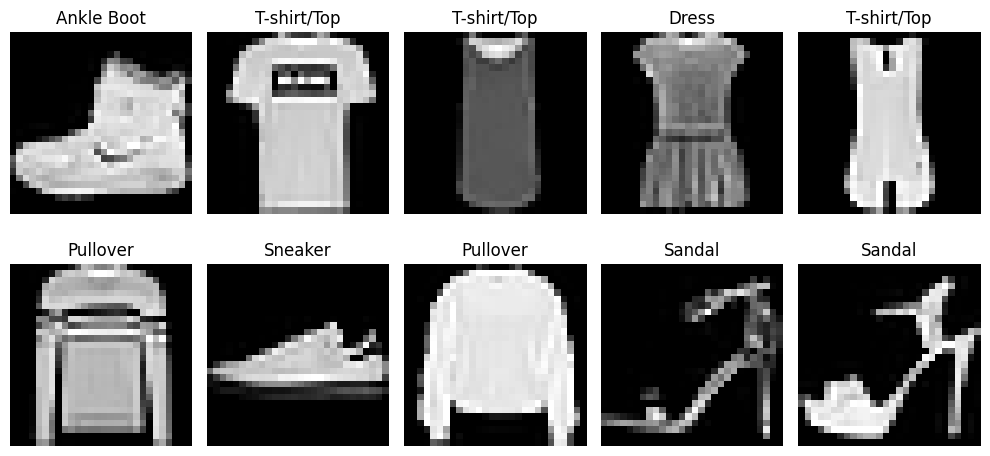

In [2]:
class_names = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

fig, axes = plt.subplots(2,5, figsize=(10,5))
for ax, img, label in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(img.reshape(28,28), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()

## Part 1: Exploratory Analysis (10 pts)

1. Describe the dataset.
2. Explain why dimensionality reduction may be useful.
3. What classes do you expect to be difficult to separate?

1. The data set contains 70,000 grayscale images of clothes (10 different clothes types/classes). Each image is 28x28 pixels, making 784 features per image.
2. Since each of the 70,000 images has 784 features, dimensionality reduction can signifigantly reduce that. Less features makes it quicker and easier to train models and can reduce noise.
3. Classes that are similar to each other might be difficult to separate, such as t-shirt/top vs shirt, coat vs pullover, and ankle boot vs sandal.

## Helper Functions (Provided)

In [3]:
def plot_embedding(X_emb, labels, title):
    plt.figure(figsize=(7,6))
    plt.scatter(X_emb[:,0], X_emb[:,1], c=labels, cmap="tab10", s=4, alpha=0.7)
    plt.title(title)
    plt.show()

def evaluate_knn(X_reduced, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, y, test_size=0.3, stratify=y, random_state=42
    )

    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)

    return accuracy_score(y_test, model.predict(X_test))

## Part 2: Visualization Study (25 pts)

Use a 5,000-sample subset for visualization.

In [4]:
X_scaled = StandardScaler().fit_transform(X)

rng = np.random.RandomState(42)
idx = rng.choice(len(X_scaled), 5000, replace=False)
X_vis = X_scaled[idx]
y_vis = y[idx]

Running PCA...


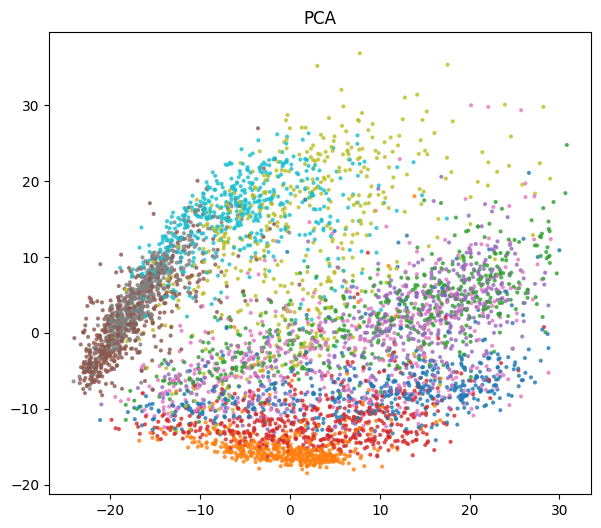

Running Random Projection...


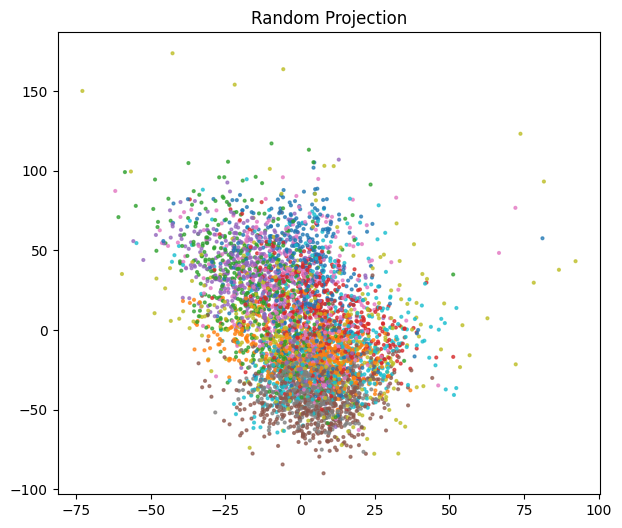

Running Isomap...


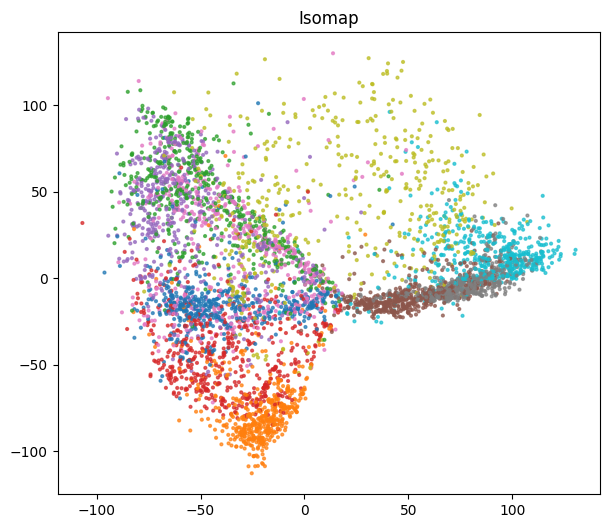

Running LLE...


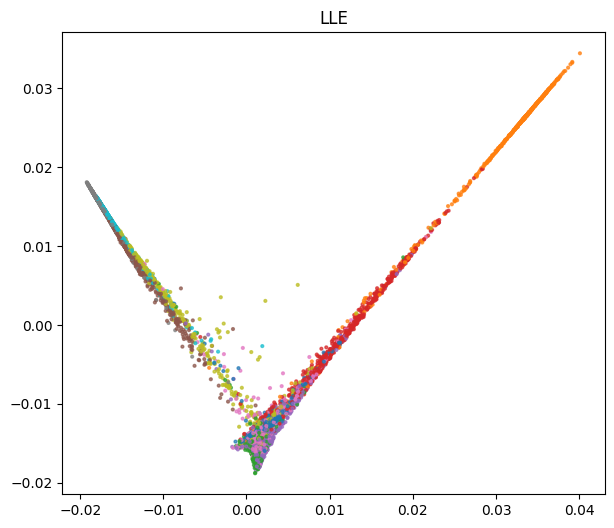

Running t-SNE...


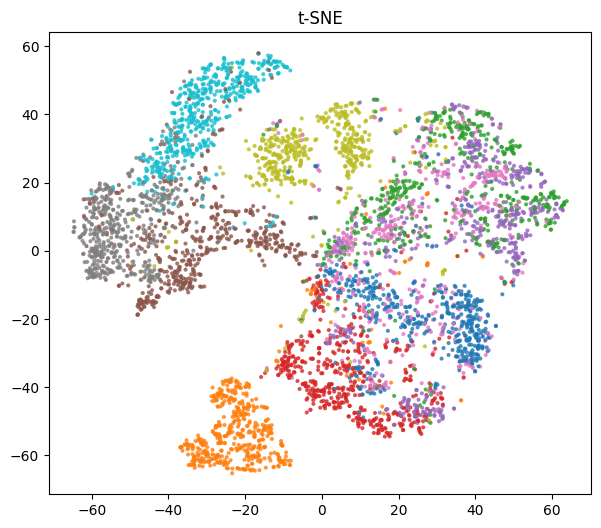

In [5]:
methods = {
    "PCA": PCA(n_components=2),
    "Random Projection": GaussianRandomProjection(n_components=2, random_state=42),
    "Isomap": Isomap(n_components=2),
    "LLE": LocallyLinearEmbedding(n_components=2, n_neighbors=15),
    "t-SNE": TSNE(n_components=2, random_state=42)
}

embeddings = {}

for name, model in methods.items():
    print(f"Running {name}...")
    emb = model.fit_transform(X_vis)
    embeddings[name] = emb
    plot_embedding(emb, y_vis, name)

### Questions
1. Which method produces the clearest clusters?
2. Which classes overlap the most?
3. Do manifold learning methods outperform PCA visually?

1. t-SNE
2. Overlapping between:
Sandal, Sneaker, Ankle Boot
Pullover, Coat, Shirt, T-shirt/Top

3. Yes, manifold learning techniques (like t-SNE) are better at visually displaying clusters than PCA for non-linear structures like this data set.

## Part 3: PCA Variance Analysis (10 pts)

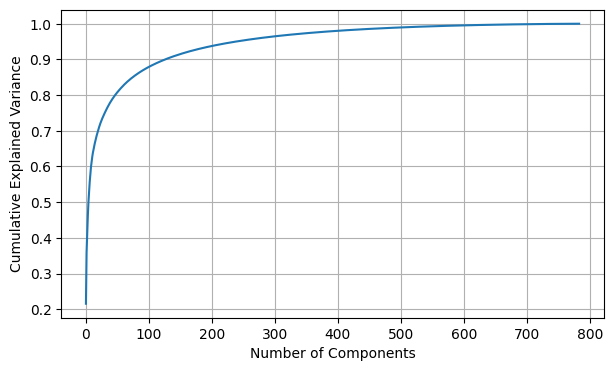

Number of components to preserve 90% variance: 127
Number of components to preserve 95% variance: 240
Number of components to preserve 99% variance: 506


In [6]:
pca_full = PCA()
pca_full.fit(X_scaled[:10000])

cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(cumulative)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# TODO: Write Code to determine the EXACT number of dimensions required to preserve 90%, 95%, and 99% variance. Do not just give rough estimates based on the plot.
n_components_90 = np.argmax(cumulative >= 0.90) + 1
n_components_95 = np.argmax(cumulative >= 0.95) + 1
n_components_99 = np.argmax(cumulative >= 0.99) + 1
print(f"Number of components to preserve 90% variance: {n_components_90}")
print(f"Number of components to preserve 95% variance: {n_components_95}")
print(f"Number of components to preserve 99% variance: {n_components_99}")

### Questions
1. What exact number of dimensions is required to preserve 90% variance?
1. What exact number of dimensions is required to preserve 95% variance?
1. What exact number of dimensions is required to preserve 99% variance?

1. 127
2. 240
3. 506

## Part 4: Classification-Based Evaluation (20 pts)

In [7]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), 10000, replace=False)
X_eval = X_scaled[sample_idx]
y_eval = y[sample_idx]

methods = {
    "PCA": PCA(n_components=50),
    "Random Projection": GaussianRandomProjection(n_components=50, random_state=42),
    "Isomap": Isomap(n_components=50),
    "LLE": LocallyLinearEmbedding(n_components=50, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

,Method,Accuracy,Runtime (s)
0,PCA,0.815667,0.929576
3,LLE,0.804000,50.549892
2,Isomap,0.795000,51.500526
1,Random Projection,0.787000,0.024724


### Questions
1. Which method produced the best knn accuracy?
2. Which method takes the least amount of time?
3. Comment on the overall accuracy and runtime trade-offs among the 4 methods.

1. PCA
2. Random Projection
3. Random projection was the quickest, but also had the lowest accuracy. Generally, the longer runtimes meant higher accuracy. The exception is PCA, which has a quicker run-time but had good accuracy. PCA & random projection is significantly faster than manifold learning methods.

## Part 5: Trustworthiness Analysis (10 pts)

Trustworthiness in dimensionality reduction is a data quality metric that measures how accurately a low-dimensional embedding preserves the local neighborhood structure of the original high-dimensional space without introducing false neighbors.

In [8]:
trust_scores=[]

for name, emb in embeddings.items():
    score=trustworthiness(X_vis, emb)
    trust_scores.append([name, score])

pd.DataFrame(trust_scores, columns=["Method","Trustworthiness"]).sort_values("Trustworthiness", ascending=False)

,Method,Trustworthiness
4,t-SNE,0.983962
3,LLE,0.875993
0,PCA,0.875287
2,Isomap,0.872152
1,Random Projection,0.699218


### Questions
1. Which method produced the best trustworthiness?
2. Which method produced the worst trustworthiness?
3. Comment on the relationship between the trustworthiness scores and the plots generated in Part 2: Visualization Study.

1. t-SNE
2. Random projection
3. The methods with higher trustworthiness produced clearer clusters, and vice versa. Random projection had no clusters (since it's random!) and had the lowest trustworthiness.

## Part 6: Dimensionality vs Accuracy (25 pts)

In Part 4, sample code was provided to compare knn accuracies of the various dimentionality reduction methods when dimensions are reduced to 50 using a subset of 10000 instances. Now expand the experiment to make similar comparisions when dimensions are reduced to 2, 5, 10, 20, 50, and 100. Be sure to create a single line chart comparing knn accuracies for different reduced dimension sizes across all methods.

In [12]:
dimensions=[2,5,10,20,50,100]

# Complete this experiment for PCA, Random Projection, Isomap, and LLE
# Create a single line chart comparing knn accuracies for different reduced dimension sizes across all methods.
methods = {
    "PCA": PCA(n_components=2),
    "Random Projection": GaussianRandomProjection(n_components=2, random_state=42),
    "Isomap": Isomap(n_components=2),
    "LLE": LocallyLinearEmbedding(n_components=2, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension2 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

methods = {
    "PCA": PCA(n_components=5),
    "Random Projection": GaussianRandomProjection(n_components=5, random_state=42),
    "Isomap": Isomap(n_components=5),
    "LLE": LocallyLinearEmbedding(n_components=5, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension5 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

methods = {
    "PCA": PCA(n_components=10),
    "Random Projection": GaussianRandomProjection(n_components=10, random_state=42),
    "Isomap": Isomap(n_components=10),
    "LLE": LocallyLinearEmbedding(n_components=10, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension10 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

methods = {
    "PCA": PCA(n_components=20),
    "Random Projection": GaussianRandomProjection(n_components=20, random_state=42),
    "Isomap": Isomap(n_components=20),
    "LLE": LocallyLinearEmbedding(n_components=20, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension20 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

methods = {
    "PCA": PCA(n_components=50),
    "Random Projection": GaussianRandomProjection(n_components=50, random_state=42),
    "Isomap": Isomap(n_components=50),
    "LLE": LocallyLinearEmbedding(n_components=50, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension50 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

methods = {
    "PCA": PCA(n_components=100),
    "Random Projection": GaussianRandomProjection(n_components=100, random_state=42),
    "Isomap": Isomap(n_components=100),
    "LLE": LocallyLinearEmbedding(n_components=100, n_neighbors=15)
}

results=[]

for name, model in methods.items():
    start=time.perf_counter()
    X_red=model.fit_transform(X_eval)
    runtime=time.perf_counter()-start
    acc=evaluate_knn(X_red,y_eval)
    results.append([name,acc,runtime])

dimension100 = pd.DataFrame(results, columns=["Method","Accuracy","Runtime (s)"]).sort_values("Accuracy", ascending=False)

              Method  Accuracy  Runtime (s)
3                LLE  0.597667    11.263902
2             Isomap  0.570667    26.224434
0                PCA  0.504333     1.393963
1  Random Projection  0.271333     0.016431               Method  Accuracy  Runtime (s)
2             Isomap  0.747333    25.789779
0                PCA  0.714333     0.910679
3                LLE  0.704667    11.199623
1  Random Projection  0.482333     0.015716               Method  Accuracy  Runtime (s)
2             Isomap  0.782333    67.645533
0                PCA  0.754667     0.812291
3                LLE  0.746667    81.658631
1  Random Projection  0.647333     0.016195               Method  Accuracy  Runtime (s)
0                PCA  0.798333     1.463166
2             Isomap  0.792667    86.769727
3                LLE  0.787000    83.405406
1  Random Projection  0.732000     0.020961               Method  Accuracy  Runtime (s)
0                PCA  0.815667     1.158393
3                LLE  0.804000  

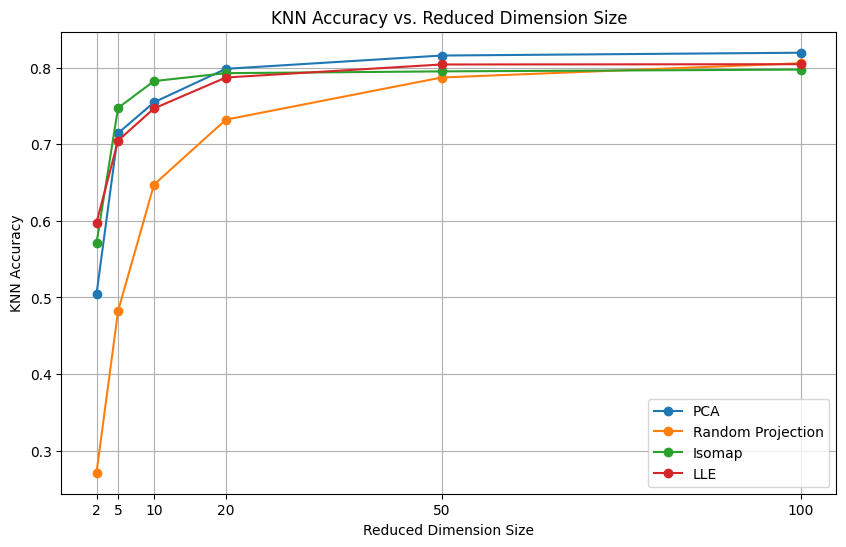

In [16]:
print(dimension2, dimension5, dimension10, dimension20, dimension50, dimension100)
import matplotlib.pyplot as plt
import pandas as pd

dimensions = [2, 5, 10, 20, 50, 100]
dfs = [dimension2, dimension5, dimension10, dimension20, dimension50, dimension100]

# Combine accuracy results for each dimension
accuracy_data = pd.DataFrame({
    "Dimension": dimensions,
    **{
        method: [
            df.loc[df["Method"] == method, "Accuracy"].iloc[0]
            for df in dfs
        ]
        for method in ["PCA", "Random Projection", "Isomap", "LLE"]
    }
})

# Plot
plt.figure(figsize=(10, 6))

for method in ["PCA", "Random Projection", "Isomap", "LLE"]:
    plt.plot(
        accuracy_data["Dimension"],
        accuracy_data[method],
        marker="o",
        label=method
    )

plt.xlabel("Reduced Dimension Size")
plt.ylabel("KNN Accuracy")
plt.title("KNN Accuracy vs. Reduced Dimension Size")
plt.xticks(dimensions)
plt.legend()
plt.grid(True)
plt.show()


### Questions
1. Commen on knn accuracies for different reduced dimension sizes across all methods.
2. Commen on running times for different reduced dimension sizes acorss all methods.
3. Which dimensionality reduction method would you choose for this dataset, and what would be a good reduced dimension size? Also Comment on the overall accuracy and running time trade-off.

1. Accuracy increased with larger dimension size for all methods, and vice versa.
2. Running times were smaller for smaller dimension sizes, and vice versa.
3. I would choose PCA since it has the highest accuracy for this data set and is quicker than the manifold learning methods. The best dimension size would be 50, since after that the increase in accuracy is minimal. Since it's not a manifold learning method, it has much faster run times (ranging from ~0.9s to 1.5s). The run time is pretty consistent across different sizes (and also takes less time), unlike the other methods.